# ERA5 Time-Series Analysis: Daily trend calculation

The ERA5 daily time series data are available here: https://www.dropbox.com/scl/fo/xuzjrgwenlvp10sq548i6/ANh2-wE3i7RllOZ4xv0ijc4?rlkey=s2ivlci4do87ffj5fxe31vz1a&st=uhnbgfgk&dl=0


When working with multi-decade climate datasets like ERA5, data is frequently partitioned into annual files to keep file sizes manageable. This notebook demonstrates an optimized pipeline to:

1. **Load and Combine:** Use `xarray` and `dask` to lazily concatenate years of data without filling up system RAM.
2. **De-seasononalize:** Calculate a daily rolling climatology and subtract it to isolate the climate anomaly signal.
3. **Mean Linear Regression:** Calculate the long-term trend of the mean signal.
4. **OPTIONAL: Quantile/Percentile Regression:** Analyze changes in extreme values (e.g., the 95th percentile of temperature) over time.

# Example: Manual calculation of a single chunk loaded from multiple files

In [2]:
import glob
import dask.array as da
import numpy as np
import scipy.stats as stats
import xarray as xr

import os
import glob
import numpy as np
import xarray as xr
import pandas as pd
# Core parallel computing initialization
from dask.distributed import Client, LocalCluster
import matplotlib.pyplot as plt

# Define your area of interest (e.g., bounding box)
#lon:-75 to -50
#lat:10 to -40
min_lon, max_lon = -75, -65
min_lat, max_lat = 0,10

def subset_area(ds):
    # Subset by bounding box using .sel()
    return ds.sel(longitude=slice(min_lon, max_lon), latitude=slice(max_lat, min_lat))

# Find all netCDF files
data_dir = "./ERA5_daily_T2m"
file_pattern = os.path.join(data_dir, "*.nc")
file_list = sorted(glob.glob(file_pattern))

# Open and combine multiple files while applying the spatial subset
ds = xr.open_mfdataset(    file_list,
    combine="by_coords",
    parallel=True,
     preprocess=subset_area)
ds = ds.chunk({"valid_time": -1, "latitude": -1, "longitude": -1})

In [5]:
t2m = np.array(ds['t2m'].data)

In [6]:
t2m.shape

(19723, 101, 101)

In [7]:
print('Size in MB: %1.2f'%round(t2m.nbytes / 1024 / 1024,2))

Size in MB: 767.50


In [8]:
datevec = np.asarray(ds.valid_time.data)
month_vector = pd.to_datetime(datevec).month.values
anomalies = np.full(t2m.shape, np.nan, dtype=np.float32)

for i in range(1,13):
        # Find rows corresponding to the current month (e.g., all Septembers)
        month_indices = (month_vector == i)
        
        # Isolate the data for that specific calendar month across all years
        sub_matrix = t2m[month_indices, :]
        
        # Calculate the historical mean for this month per pixel (collapsing time axis)
        month_mean = np.nanmean(sub_matrix, axis=0)
        
        # Subtract the mean from all occurrences of this month
        anomalies[month_indices, :] = sub_matrix - month_mean

/tmp/ipykernel_1768701/2492618367.py:13: RuntimeWarning: Mean of empty slice
  month_mean = np.nanmean(sub_matrix, axis=0)


In [9]:
date_daily = np.arange(0, len(datevec),1)
# could also do daily values - and results will be in T/day
#date_daily = (datevec - datevec.min()) / np.timedelta64(1, "D")
#Design Marix:
A = np.vstack([date_daily, np.ones(len(date_daily))]).T
# Target Matrix - flatten array in spatial dimension:
Y = anomalies.reshape(len(date_daily), anomalies.shape[1]*anomalies.shape[2])
print(A.shape)
print(anomalies.shape)
print(Y.shape)

(19723, 2)
(19723, 101, 101)
(19723, 10201)


In [12]:
%%time
coefficients, residuals, rank, s = np.linalg.lstsq(A, Y, rcond=None)

# R2
# 1. Compute predicted values for all pixels using matrix multiplication
# (Time, 2) dot (2, N_valid_pixels) -> Shape: (Time, N_valid_pixels)
y_pred = np.dot(A, coefficients)

# 2. Sum of Squared Residuals (SS_res) along the time axis (axis=0)
ss_res = np.sum((Y - y_pred) ** 2, axis=0)

# 3. Total Sum of Squares (SS_tot) along the time axis (axis=0)
y_mean = np.mean(Y, axis=0)
ss_tot = np.sum((Y - y_mean) ** 2, axis=0)

# SAFE DIVISION: Only divide where ss_tot is greater than 0. 
    # Everywhere else (like flat lines or constant values), default the R² to NaN.
r_squared = np.where(ss_tot > 0, 1.0 - (ss_res / ss_tot), np.nan)
# convert to grid
r_squared = r_squared.reshape(anomalies.shape[1], anomalies.shape[2])

n_time = t2m.shape[0]

df = n_time - 2
f_stat = (r_squared / (1.0 - r_squared)) * df
p_val = 1.0 - stats.f.cdf(f_stat, 1, df)


CPU times: user 9.18 s, sys: 663 ms, total: 9.84 s
Wall time: 2.36 s


In [42]:
#remember: first coefficient is slope
slope_map = coefficients[0,:].reshape(anomalies.shape[1],anomalies.shape[2])
print(slope_map.shape)

(101, 101)


(<matplotlib.image.AxesImage at 0x7f3a7f9c37d0>,
 Text(0.5, 1.0, 'Linear regression T slope in K/decade'))

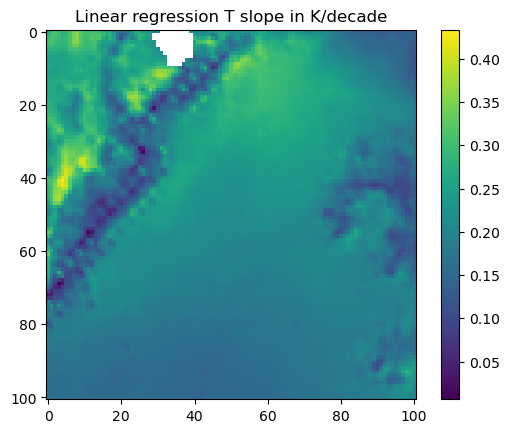

In [43]:
plt.imshow(slope_map*365.25*10), plt.colorbar(), plt.title('Linear regression T slope in K/decade')

# Use dask to compute all chunks

Optimized code running through all chunks and perform regression on 2 cores (16 GB each core). If you have more memory available, you can run on more cores. We use 6 threads per core (this is for the lst-squared regression).

In [1]:
import glob
import os, time, warnings
import dask.array as da
import numpy as np
import pandas as pd
import scipy.stats as stats
import xarray as xr
from dask.distributed import Client, LocalCluster
import matplotlib.pyplot as plt

warnings.filterwarnings(action='ignore', message='Mean of empty slice')
np.errstate(invalid='ignore', divide='ignore')

# ==============================================================================
# 1. FIXED VECTORIZED WORKER FUNCTION
# ==============================================================================
def xarray_numpy_regression(ts_chunk):
    """Processes a 3D Xarray DataArray chunk (time, lat, lon) dynamically.

    Returns a 2D Xarray Dataset containing slope, p_value, and r_squared.
    """
    # 1. Grab dimensions of the current incoming chunk
    n_time = len(ts_chunk.valid_time)
    n_lat = len(ts_chunk.latitude)
    n_lon = len(ts_chunk.longitude)

    # 2. Extract underlying NumPy array values directly
    # Inside map_blocks, ts_chunk.values is already a regular NumPy array
    t2m = ts_chunk.values

    # 3. Compute time vectors dynamically inside the chunk to ensure perfect alignment
    datevec = ts_chunk.valid_time.values
    month_vector = pd.to_datetime(datevec).month.values
    date_daily = np.arange(0, n_time, 1)

    # 4. Perform Climatology/Anomaly extraction inside the NumPy chunk
    anomalies = np.full(t2m.shape, np.nan, dtype=np.float32)
    with warnings.catch_warnings():
        warnings.filterwarnings(
                "ignore", message="Mean of empty slice", category=RuntimeWarning
        )    
        for i in range(1, 13):
            month_indices = month_vector == i
            if not np.any(month_indices):
                continue
    
            # Isolate the data for that specific calendar month
            sub_matrix = t2m[month_indices, :, :]
    
            # Calculate historical mean per pixel for this month
            month_mean = np.nanmean(sub_matrix, axis=0)
    
            # Subtract the mean
            anomalies[month_indices, :, :] = sub_matrix - month_mean

    # 5. Build Matrices for Linear Algebra
    # Design Matrix (Time, 2)
    A = np.vstack([date_daily, np.ones(n_time)]).T

    # Target Matrix flattened in spatial dimension -> Shape: (Time, Lat * Lon)
    Y = anomalies.reshape(n_time, n_lat * n_lon)

    # 6. Run the Least Squares regression simultaneously on all pixels
    coefficients, residuals, rank, s = np.linalg.lstsq(A, Y, rcond=None)

    # Separate slopes and intercepts from the coefficients matrix
    # coefficients shape: (2, Lat * Lon) -> row 0 is slopes, row 1 is intercepts
    slopes_flat = coefficients[0, :]

    # 7. Compute R-Squared
    # (Time, 2) dot (2, Lat*Lon) -> Shape: (Time, Lat*Lon)
    y_pred = np.dot(A, coefficients)
    ss_res = np.sum((Y - y_pred) ** 2, axis=0)

    y_mean = np.mean(Y, axis=0)
    ss_tot = np.sum((Y - y_mean) ** 2, axis=0)

    # Safe Division for R²
    r_squared_flat = np.where(ss_tot > 0, 1.0 - (ss_res / ss_tot), np.nan)

    # 8. Compute P-Value via F-Statistic
    df = n_time - 2
    with np.errstate(invalid="ignore", divide="ignore"):
        f_stat = (r_squared_flat / (1.0 - r_squared_flat)) * df
        p_val_flat = 1.0 - stats.f.cdf(f_stat, 1, df)

    # 9. Reshape flat vectors back to the EXACT spatial dimensions of this chunk
    slopes = slopes_flat.reshape(n_lat, n_lon)
    r_squares = r_squared_flat.reshape(n_lat, n_lon)
    p_values = p_val_flat.reshape(n_lat, n_lon)

    # 10. Wrap back into a clean 2D Xarray Dataset
    chunk_result = xr.Dataset(
        data_vars={
            "slope": (["latitude", "longitude"], slopes),
            "p_value": (["latitude", "longitude"], p_values),
            "r_squared": (["latitude", "longitude"], r_squares),
        },
        coords={
            "latitude": ts_chunk.latitude,
            "longitude": ts_chunk.longitude,
        },
    )

    return chunk_result


# ==============================================================================
# 2. DASK PIPELINE INITIALIZATION
# ==============================================================================
if __name__ == "__main__":
    # Setup Data Directories
    data_dir = "./ERA5_daily_T2m"
    file_pattern = os.path.join(data_dir, "*.nc")
    file_list = sorted(glob.glob(file_pattern))

    # Initialize Local Cluster
    cluster = LocalCluster(
        n_workers=2, threads_per_worker=6, memory_limit="16GB"
    )
    client = Client(cluster)
    print(f"Dask dashboard active at: {client.dashboard_link}")

    # Open multi-file datasets lazily with clean graph constraints
    ds = xr.open_mfdataset(
        file_list,
        combine="by_coords",
        parallel=True,
        coords="minimal",
        data_vars="minimal",
        compat="override",
    )

    # Chunk dataset cleanly (Time dimension MUST be unbroken (-1))
    ds = ds.chunk({"valid_time": -1, "latitude": 100, "longitude": 100})

    # Extract global dimensions and structural chunk footprints
    n_global_lat = len(ds.latitude)
    n_global_lon = len(ds.longitude)
    lat_chunks = ds["t2m"].chunks[1]
    lon_chunks = ds["t2m"].chunks[2]

    # Build Template with lazy Dask arrays matching spatial chunk blueprints
    template = xr.Dataset(
        data_vars={
            "slope": (
                ["latitude", "longitude"],
                da.empty(
                    (n_global_lat, n_global_lon),
                    chunks=(lat_chunks, lon_chunks),
                    dtype=float,
                ),
            ),
            "p_value": (
                ["latitude", "longitude"],
                da.empty(
                    (n_global_lat, n_global_lon),
                    chunks=(lat_chunks, lon_chunks),
                    dtype=float,
                ),
            ),
            "r_squared": (
                ["latitude", "longitude"],
                da.empty(
                    (n_global_lat, n_global_lon),
                    chunks=(lat_chunks, lon_chunks),
                    dtype=float,
                ),
            ),
        },
        coords={
            "latitude": ds.latitude,
            "longitude": ds.longitude,
        },
    )

    start = time.time()
    # Reset graph complexity by cleanly mapping your DataArray block execution
    output_ds = xr.map_blocks(
        xarray_numpy_regression, ds["t2m"], template=template
    ).compute()    
    dask_parallel_trend_duration = time.time() - start
    print(f"Dask map_blocks with numpy regression: {dask_parallel_trend_duration:.2f} seconds or {dask_parallel_trend_duration/60:.2f} minutes!")

    # Stream computations directly to your file system
    print("Streaming calculations chunk-by-chunk directly to disk...")
    output_ds.to_netcdf("ERA5_SAM_daily_T2m_slope_r2_pvalue_regression_results.nc")
    print("Done! Check your working directory for ERA5_SAM_daily_T2m_slope_r2_pvalue_regression_results.nc")

Dask dashboard active at: http://127.0.0.1:8787/status


2026-06-21 19:16:10,246 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 3a139d79c7613e2f1f6d0c992cac2c3d initialized by task ('rechunk-merge-rechunk-transfer-838528b998c8f8b4fb9014b3f4bc5b38', 0, 4, 2, 1, 4, 2) executed on worker tcp://127.0.0.1:38581
2026-06-21 19:16:10,284 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle c230f18cff1775cc0581d6d124da2e27 initialized by task ('rechunk-merge-rechunk-transfer-838528b998c8f8b4fb9014b3f4bc5b38', 0, 4, 1, 1, 4, 1) executed on worker tcp://127.0.0.1:38581
2026-06-21 19:16:12,390 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 3a139d79c7613e2f1f6d0c992cac2c3d deactivated due to stimulus 'task-finished-1782062172.3878138'
2026-06-21 19:16:12,572 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle c230f18cff1775cc0581d6d124da2e27 deactivated due to stimulus 'task-finished-1782062172.5710566'
/tmp/ipykernel_1781969/3451276288.py:50: RuntimeWarning: Mean of empty slice
2026-06-21 19:16:16,388 - distribut

Dask map_blocks with numpy regression: 33.37 seconds or 0.56 minutes!
Streaming calculations chunk-by-chunk directly to disk...
Done! Check your working directory for ERA5_SAM_daily_T2m_slope_r2_pvalue_regression_results.nc


In [2]:
output_ds

<xarray.Dataset> Size: 3MB
Dimensions:    (latitude: 501, longitude: 251)
Coordinates:
  * latitude   (latitude) float64 4kB 10.0 9.9 9.8 9.7 ... -39.8 -39.9 -40.0
  * longitude  (longitude) float64 2kB -75.0 -74.9 -74.8 ... -50.2 -50.1 -50.0
    number     int64 8B 0
Data variables:
    p_value    (latitude, longitude) float64 1MB 1.11e-16 1.11e-16 ... nan nan
    slope      (latitude, longitude) float64 1MB 7.205e-05 8.117e-05 ... nan nan
    r_squared  (latitude, longitude) float64 1MB 0.1346 0.1466 ... nan nan

In [3]:
slope_per_decade = output_ds['slope'] * 365.25 * 10 # slope is in K/day - convert to K/decade

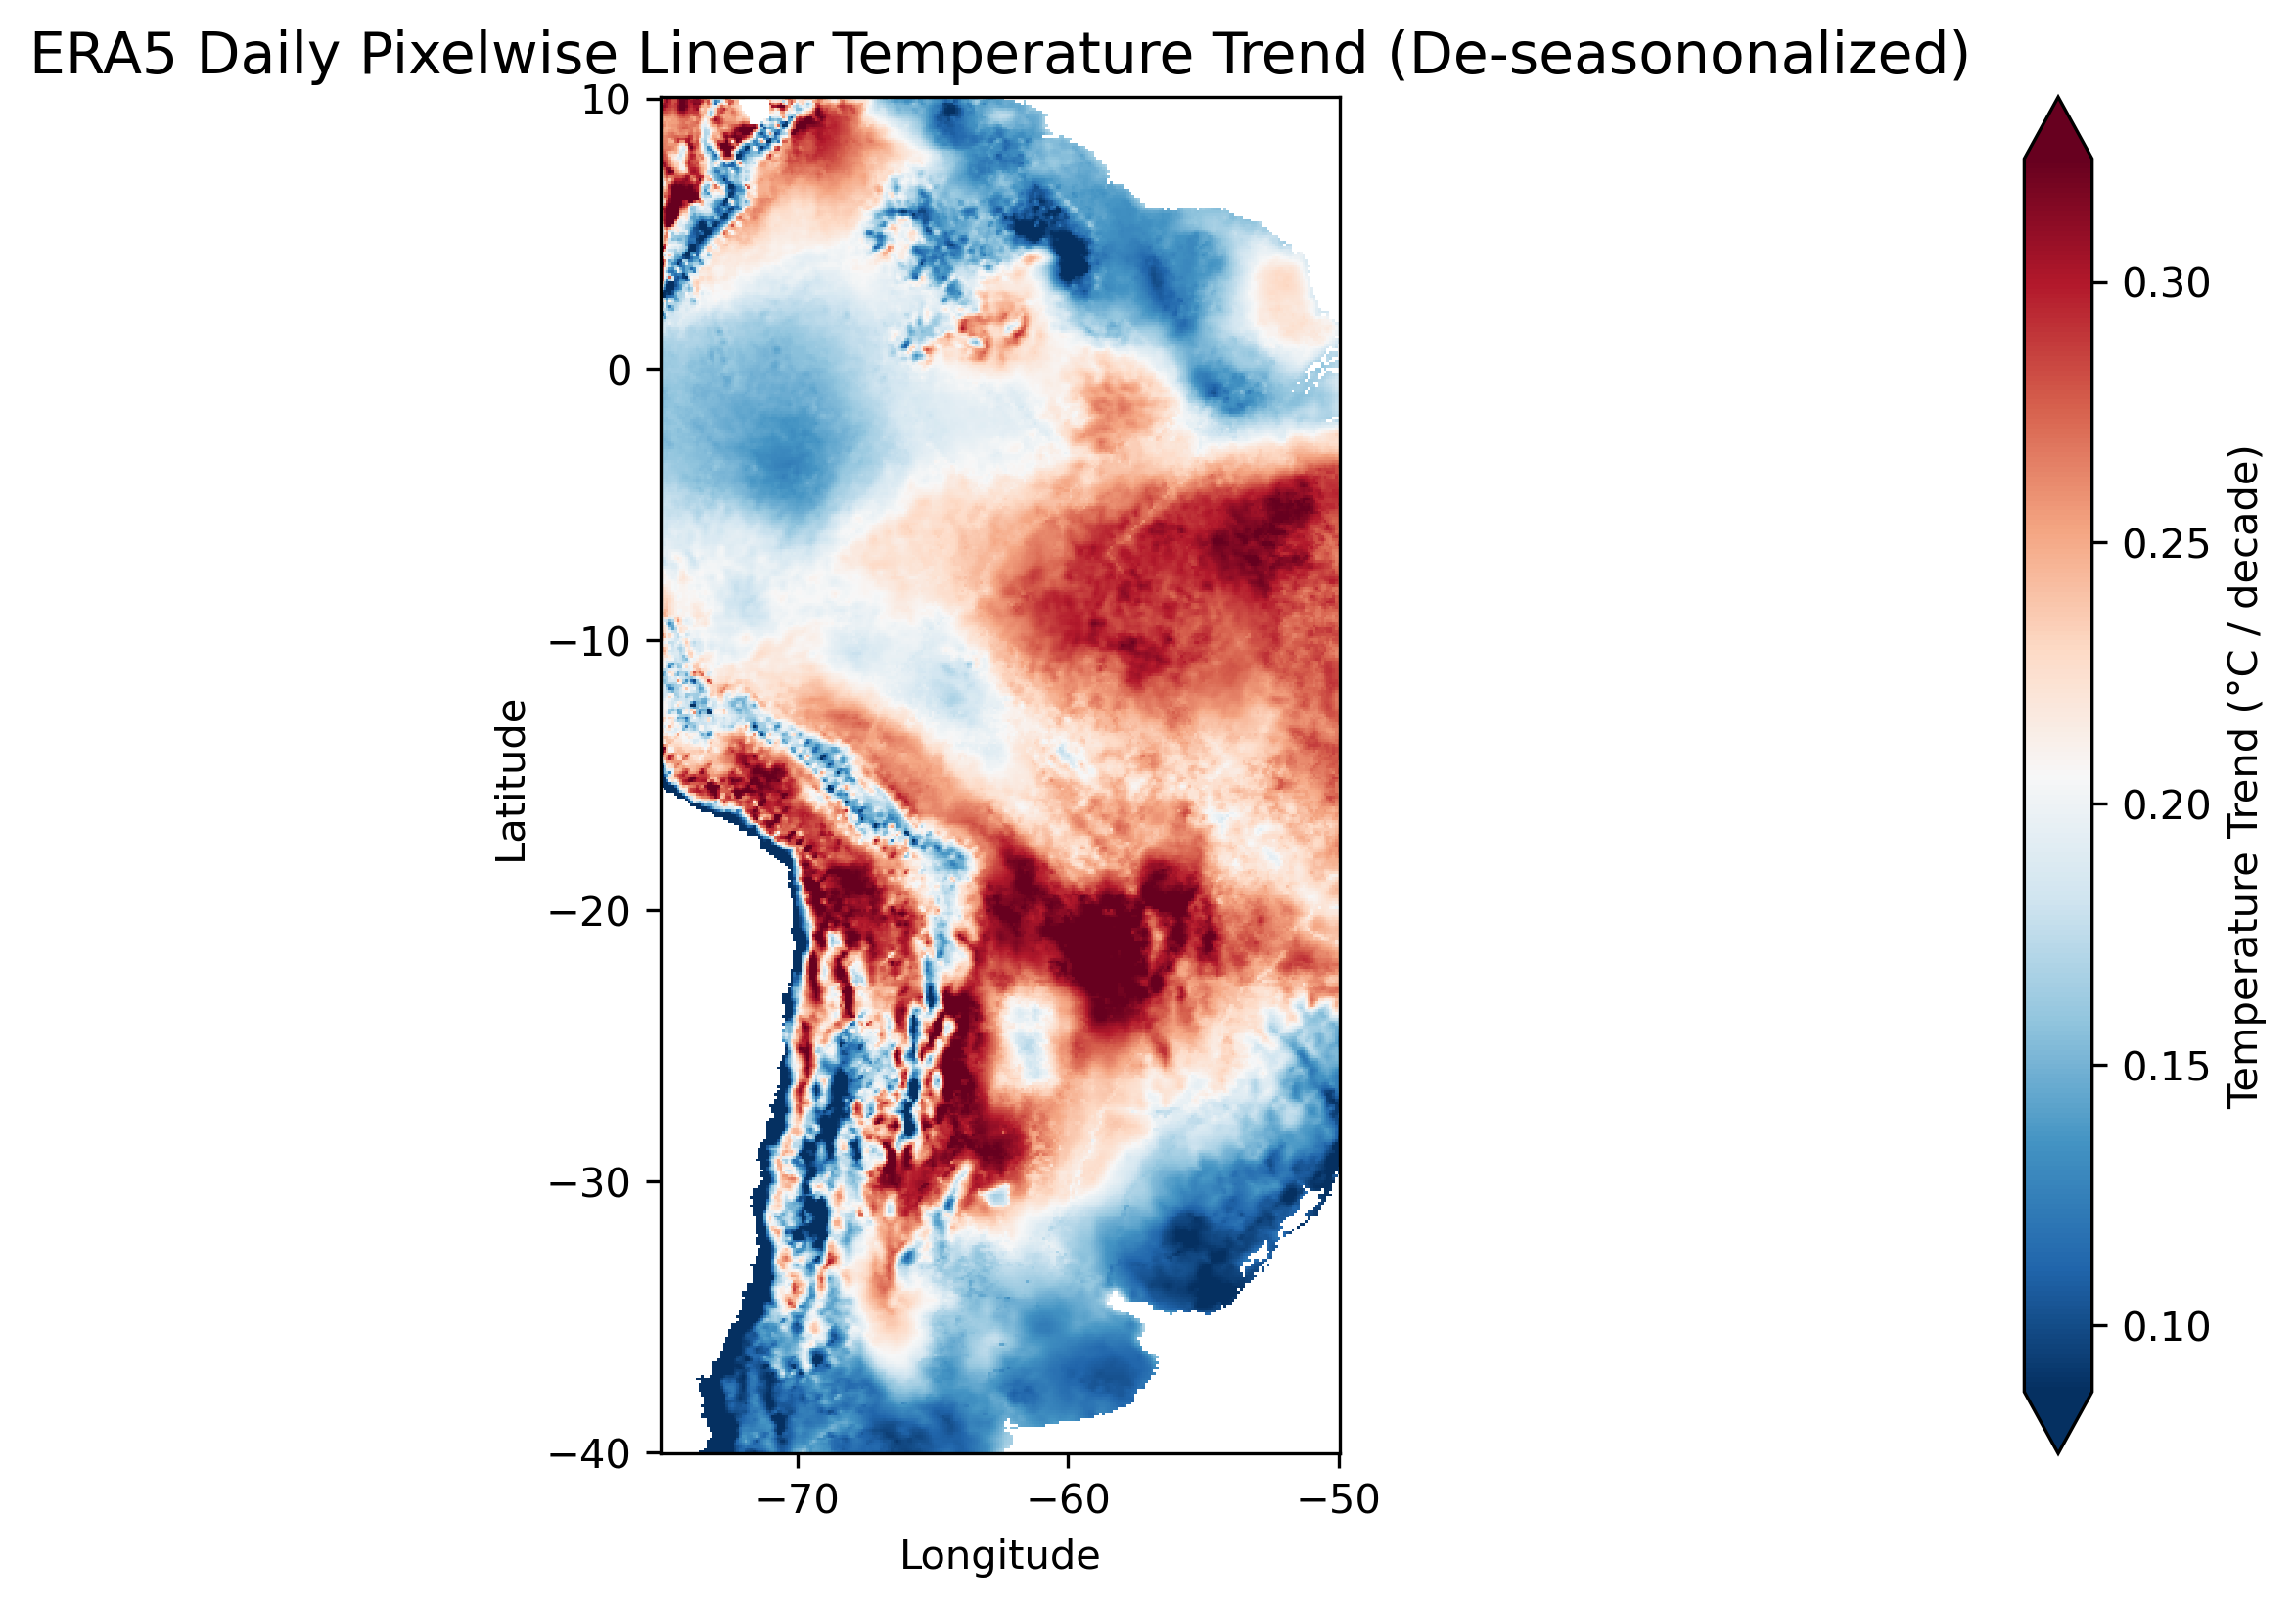

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6), dpi=300)
slope_per_decade.plot(
    cmap="RdBu_r", 
    robust=True, 
    cbar_kwargs={"label": "Temperature Trend (°C / decade)"}
)
plt.title("ERA5 Daily Pixelwise Linear Temperature Trend (De-seasononalized)", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.axis('scaled')
plt.show()

Text(0.5, 0.98, 'ERA5 Daily T2m trends, r2, and p values for 19,723 timestepes')

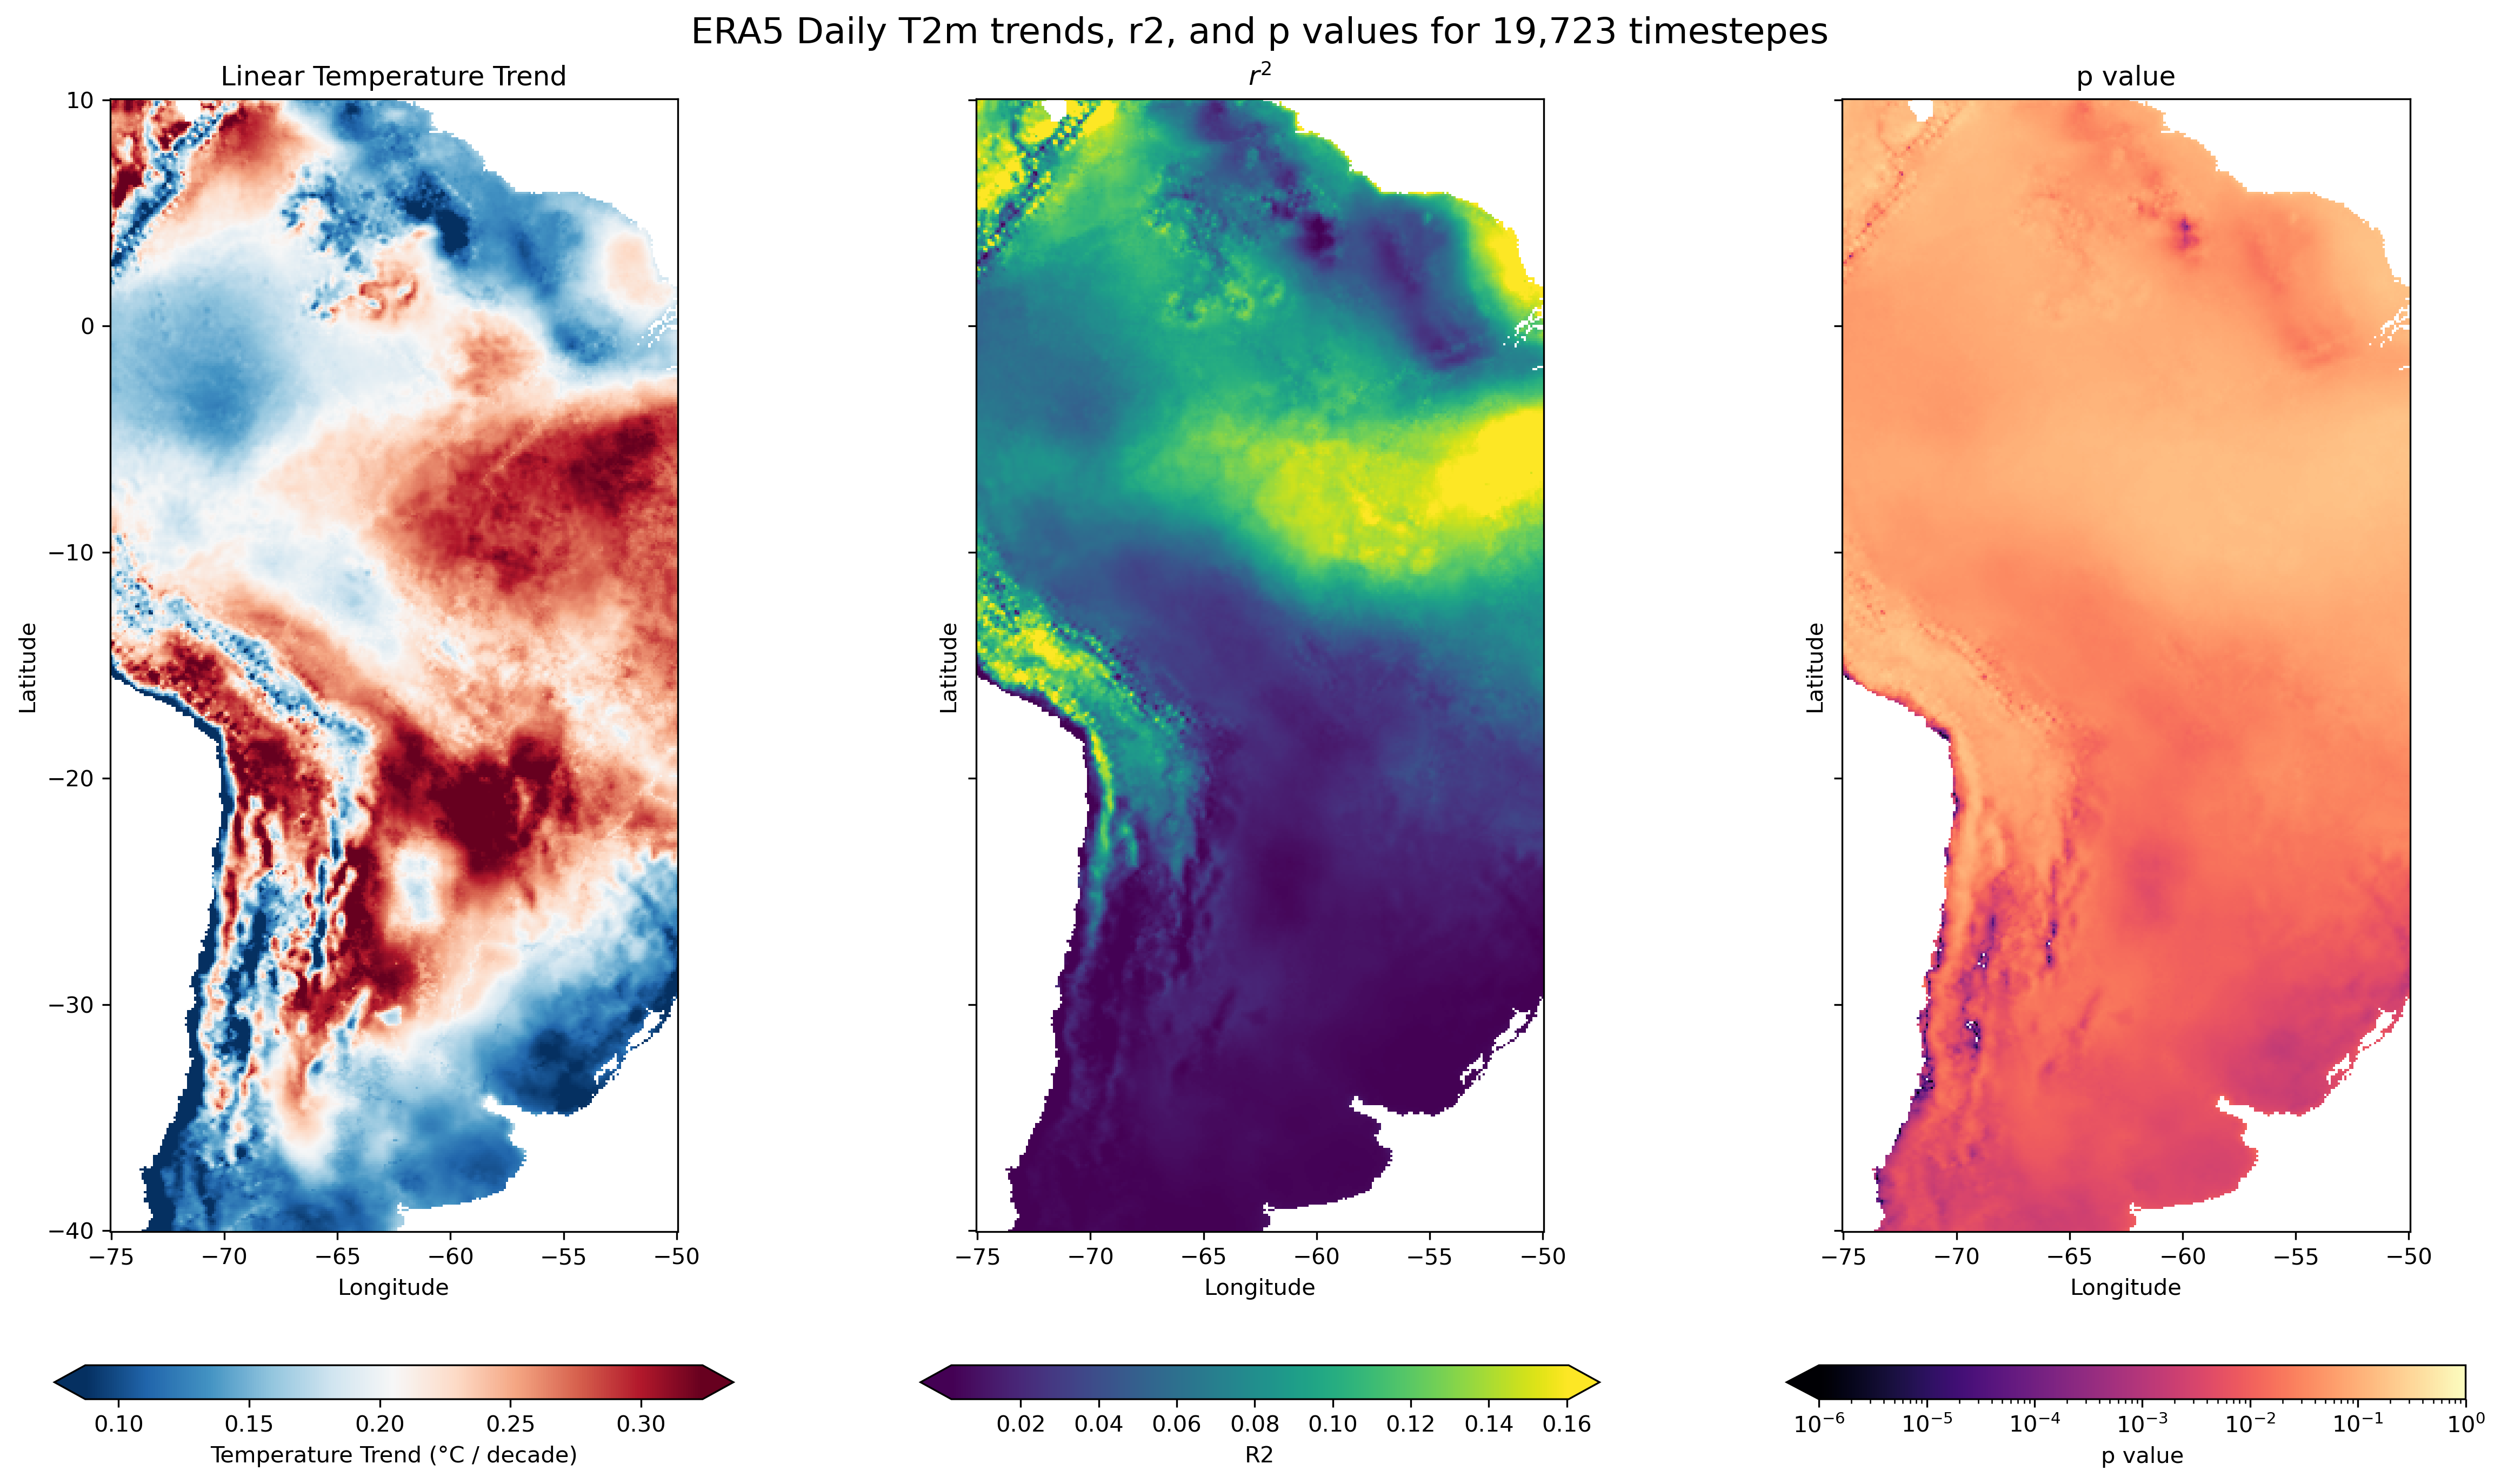

In [8]:
# Make a figure showing all attributes
import matplotlib.colors as colors

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(16,9), sharey=True, dpi=300, layout='constrained')

slope_per_decade.plot(
    cmap="RdBu_r", 
    robust=True, 
    cbar_kwargs={"label": "Temperature Trend (°C / decade)", 'shrink'
                 :0.8, 'orientation':'horizontal'},
    ax=ax[0]
)
ax[0].set_title("Linear Temperature Trend", fontsize=12)
ax[0].set_xlabel("Longitude")
ax[0].set_ylabel("Latitude")
ax[0].set_aspect('equal')

output_ds['r_squared'].plot(
    cmap="viridis", 
    robust=True, 
    cbar_kwargs={"label": "R2", 'shrink'
                 :0.8, 'orientation':'horizontal'},
    ax=ax[1]
)
ax[1].set_title(r"$r^2$", fontsize=12)
ax[1].set_xlabel("Longitude")
ax[1].set_ylabel("Latitude")
ax[1].set_aspect('equal')

output_ds['r_squared'].plot(
    cmap="magma", 
    robust=True,
    norm=colors.LogNorm(vmin=1e-6, vmax=1),
    cbar_kwargs={"label": "p value", 'shrink'
                 :0.8, 'orientation':'horizontal'},
    ax=ax[2]
)
ax[2].set_title(r"p value", fontsize=12)
ax[2].set_xlabel("Longitude")
ax[2].set_ylabel("Latitude")
ax[2].set_aspect('equal')

fig.suptitle('ERA5 Daily T2m trends, r2, and p values for %s timestepes'%f'{ds['t2m'].shape[0]:,}'   , fontsize=16)
fig.savefig('ERA5_daily_T2m_1970_2025.png')

## OPTIONAL 4. Annual Percentile (Extreme Quantile) Regression

While standard OLS tells us how the *mean* is changing, climate change often impacts **extremes** more aggressively than averages. 

Here, we will group our data by year, isolate a high extreme threshold—the **95th percentile** of temperature for each individual year—and check if our extreme summer peaks are rising faster than the median baseline.

In [ ]:
# 1. Compute the 95th percentile value for each isolated calendar year
annual_95th = ds_combined["t2m"].groupby("valid_time.year").quantile(0.95, dim="valid_time").to_dataframe().reset_index()

# Map continuous linear timeline increments based on years
annual_95th["years_since_start"] = annual_95th["year"] - annual_95th["year"].min()

print("Extracted Annual 95th Percentiles:")
print(annual_95th)

# 2. Perform Quantile Regression on the extreme parameters
# Quantile regression minimizes absolute deviations rather than squared errors
quant_model = smf.quantreg("t2m ~ years_since_start", data=annual_95th)
quant_results = quant_model.fit(q=0.5) # Evaluating the structural shift trajectory of the extreme metric boundaries

print("\n--- Percentile Regression Summary ---")
print(quant_results.summary())

extreme_slope = quant_results.params["years_since_start"]
print(f"\nExtreme (95th Percentile) trend trajectory: {extreme_slope:.4f} °C per year")

2026-06-13 17:41:32,992 - distributed.worker - ERROR - Failed to communicate with scheduler during heartbeat.
Traceback (most recent call last):
  File "/home/bodo/miniconda3/envs/geodata/lib/python3.12/site-packages/distributed/comm/tcp.py", line 226, in read
    frames_nosplit_nbytes_bin = await stream.read_bytes(fmt_size)
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/bodo/miniconda3/envs/geodata/lib/python3.12/site-packages/distributed/worker.py", line 1273, in heartbeat
    response = await retry_operation(
               ^^^^^^^^^^^^^^^^^^^^^^
  File "/home/bodo/miniconda3/envs/geodata/lib/python3.12/site-packages/distributed/utils_comm.py", line 416, in retry_operation
    return await retry(
           ^^^^^^^^^^^^
  File "/home/bodo/miniconda3/envs/geodata/lib/python3.12/site-packages/dis

## 5. Visual Summary

Let's wrap up our analytical script by overlaying both our daily anomalies and the moving extremes in a comprehensive layout plot.

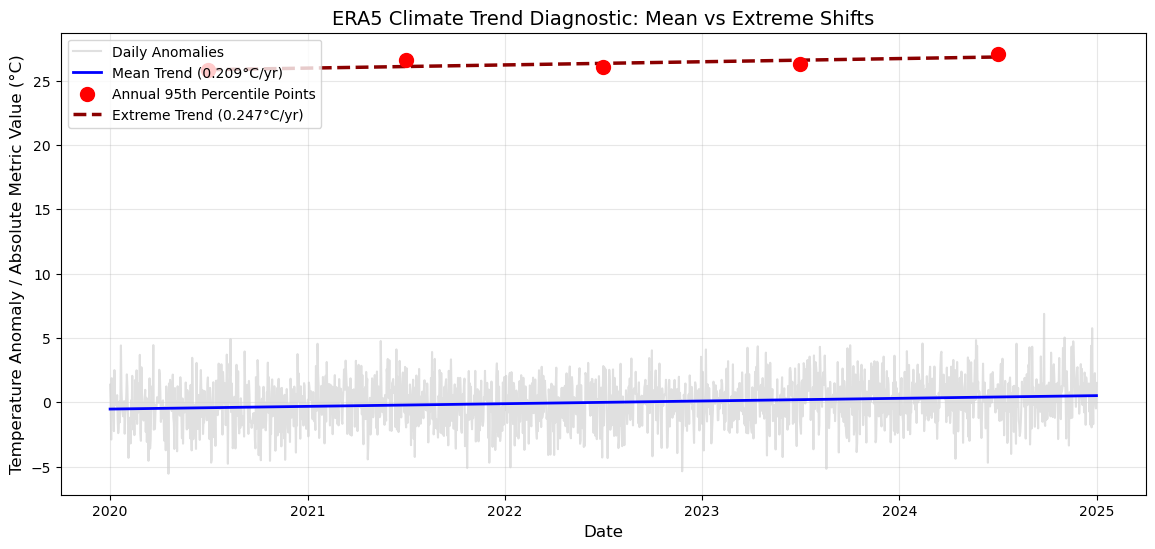

In [6]:
plt.figure(figsize=(14, 6))

# Plot raw anomalies
plt.plot(df_climate["valid_time"], df_climate["t2m"], label="Daily Anomalies", color="lightgray", alpha=0.7)

# Overlay trend line for the mean
mean_trend_line = ols_model.predict(X_mean)
plt.plot(df_climate["valid_time"], mean_trend_line, color="blue", linewidth=2, label=f"Mean Trend ({slope_per_day*365.25:.3f}°C/yr)")

# Plot Annual 95th Percentile values
# We convert year integers back to matching time coordinates for the plot overlay
time_coords = pd.to_datetime(annual_95th["year"].astype(str) + "-07-01")
plt.scatter(time_coords, annual_95th["t2m"], color="red", s=100, zorder=5, label="Annual 95th Percentile Points")

# Plot extreme trend line
extreme_trend_line = quant_results.predict(annual_95th)
plt.plot(time_coords, extreme_trend_line, color="darkred", linestyle="--", linewidth=2.5, label=f"Extreme Trend ({extreme_slope:.3f}°C/yr)")

plt.title("ERA5 Climate Trend Diagnostic: Mean vs Extreme Shifts", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Temperature Anomaly / Absolute Metric Value (°C)", fontsize=12)
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
client.close()
cluster.close()